In [1]:
!pip install pandas numpy nltk scikit-learn matplotlib wordcloud

In [2]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [4]:
data = {
    'review': [

        "Amazing acting and wonderful storyline",
        "The movie was boring and too slow",
        "Average movie with decent performances",
        "Excellent direction and fantastic music",
        "Terrible screenplay and poor acting",
        "I really loved the cinematography",
        "The story was confusing and dull",
        "Great entertainment and brilliant acting",
        "Nothing special, just okay movie",
        "Bad direction ruined the movie",
        "The web series was fantastic",
        "It was an average experience"

    ],

    'sentiment': [

        'Positive',
        'Negative',
        'Neutral',
        'Positive',
        'Negative',
        'Positive',
        'Negative',
        'Positive',
        'Neutral',
        'Negative',
        'Positive',
        'Neutral'
    ]
}

df = pd.DataFrame(data)

df.to_csv("movie_reviews.csv", index=False)

print(df)

                                      review sentiment
0     Amazing acting and wonderful storyline  Positive
1          The movie was boring and too slow  Negative
2     Average movie with decent performances   Neutral
3    Excellent direction and fantastic music  Positive
4        Terrible screenplay and poor acting  Negative
5          I really loved the cinematography  Positive
6           The story was confusing and dull  Negative
7   Great entertainment and brilliant acting  Positive
8           Nothing special, just okay movie   Neutral
9             Bad direction ruined the movie  Negative
10              The web series was fantastic  Positive
11              It was an average experience   Neutral


In [5]:
df = pd.read_csv("movie_reviews.csv")

print(df.head())

                                    review sentiment
0   Amazing acting and wonderful storyline  Positive
1        The movie was boring and too slow  Negative
2   Average movie with decent performances   Neutral
3  Excellent direction and fantastic music  Positive
4      Terrible screenplay and poor acting  Negative


In [6]:
stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()


def preprocess(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)


df['clean_review'] = df['review'].apply(preprocess)

print(df[['review', 'clean_review']])

                                      review  \
0     Amazing acting and wonderful storyline   
1          The movie was boring and too slow   
2     Average movie with decent performances   
3    Excellent direction and fantastic music   
4        Terrible screenplay and poor acting   
5          I really loved the cinematography   
6           The story was confusing and dull   
7   Great entertainment and brilliant acting   
8           Nothing special, just okay movie   
9             Bad direction ruined the movie   
10              The web series was fantastic   
11              It was an average experience   

                            clean_review  
0     amazing acting wonderful storyline  
1                      movie boring slow  
2       average movie decent performance  
3    excellent direction fantastic music  
4        terrible screenplay poor acting  
5            really loved cinematography  
6                   story confusing dull  
7   great entertainment brillia

In [7]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df['clean_review'])

y = df['sentiment']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [10]:
predictions = model.predict(X_test)

print(predictions)

['Positive' 'Positive' 'Positive']


In [11]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print(classification_report(y_test, predictions))

Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.67      1.00      0.80         2

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
new_review = ["The acting was amazing but the story was average"]

cleaned = preprocess(new_review[0])

vector = vectorizer.transform([cleaned])

prediction = model.predict(vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: Negative


In [13]:
positive_reviews = df[df['sentiment'] == 'Positive']

negative_reviews = df[df['sentiment'] == 'Negative']

neutral_reviews = df[df['sentiment'] == 'Neutral']

print("Positive Reviews:\n", positive_reviews)

print("\nNegative Reviews:\n", negative_reviews)

print("\nNeutral Reviews:\n", neutral_reviews)

Positive Reviews:
                                       review sentiment  \
0     Amazing acting and wonderful storyline  Positive   
3    Excellent direction and fantastic music  Positive   
5          I really loved the cinematography  Positive   
7   Great entertainment and brilliant acting  Positive   
10              The web series was fantastic  Positive   

                            clean_review  
0     amazing acting wonderful storyline  
3    excellent direction fantastic music  
5            really loved cinematography  
7   great entertainment brilliant acting  
10                  web series fantastic  

Negative Reviews:
                                 review sentiment  \
1    The movie was boring and too slow  Negative   
4  Terrible screenplay and poor acting  Negative   
6     The story was confusing and dull  Negative   
9       Bad direction ruined the movie  Negative   

                      clean_review  
1                movie boring slow  
4  terrible screenp

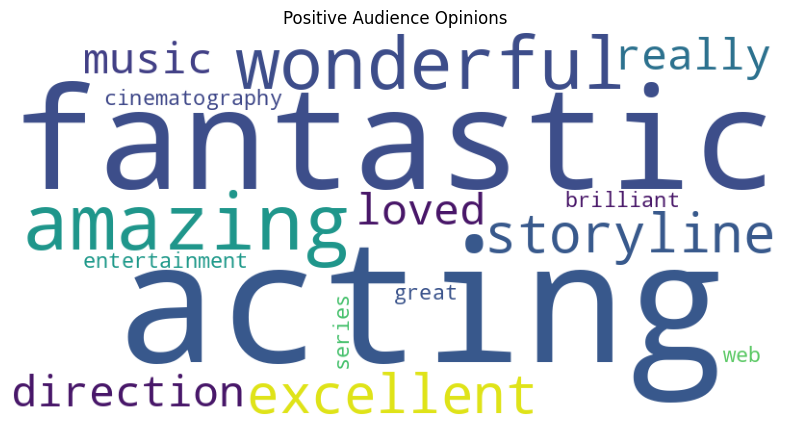

In [14]:
text = " ".join(positive_reviews['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Audience Opinions")

plt.show()

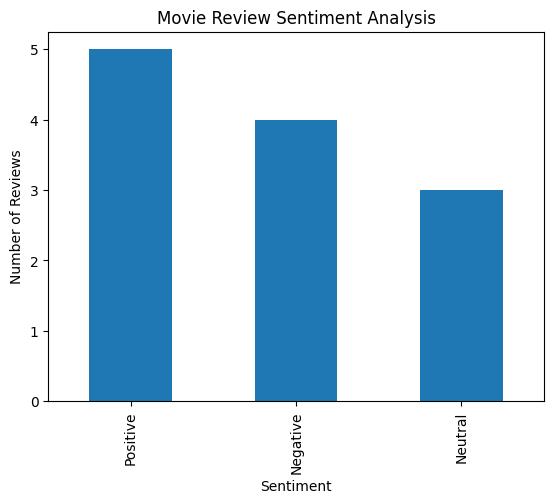

In [15]:
df['sentiment'].value_counts().plot(
    kind='bar'
)

plt.title("Movie Review Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

In [16]:
from collections import Counter

all_reviews = " ".join(df['clean_review'])

words = all_reviews.split()

common_words = Counter(words)

print(common_words.most_common(10))

[('movie', 4), ('acting', 3), ('average', 2), ('direction', 2), ('fantastic', 2), ('amazing', 1), ('wonderful', 1), ('storyline', 1), ('boring', 1), ('slow', 1)]


In [17]:
total_reviews = len(df)

positive = len(df[df['sentiment']=="Positive"])

negative = len(df[df['sentiment']=="Negative"])

neutral = len(df[df['sentiment']=="Neutral"])


print("\n------ MOVIE REVIEW ANALYSIS REPORT ------")

print("Total Reviews:", total_reviews)

print("Positive Reviews:", positive)

print("Negative Reviews:", negative)

print("Neutral Reviews:", neutral)

print("Popularity Score:",
      (positive/total_reviews)*100,"%")

print("\nMost Discussed Factors:")

for word,count in common_words.most_common(5):
    print(word, ":", count)


------ MOVIE REVIEW ANALYSIS REPORT ------
Total Reviews: 12
Positive Reviews: 5
Negative Reviews: 4
Neutral Reviews: 3
Popularity Score: 41.66666666666667 %

Most Discussed Factors:
movie : 4
acting : 3
average : 2
direction : 2
fantastic : 2
